In [12]:
# import statsmodels.api as sm

import os
import pickle
import sys
sys.path.append("/home/vrmaster/Projects/VirtualReality/analysisVR")
sys.path.append("/home/vrmaster/Projects/VirtualReality/ephysVR")


In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
# %matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [14]:
output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="DEBUG")



In [18]:
# ephys
paradigm_ids = [1100]
animal_ids = [6]
session_ids = None
# animal_ids = [10]
# session_ids = [10]
# width = 1400
# height = 1400
# group_by = None
session_dirs = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)[0]

session_names = fullfnames2snames(session_dirs)
data = analytics.get_analytics('SVMCueOutcomeChoicePred', session_names=session_names)
data

2025-09-10 09:12:39,187|DEBUG|1006778|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2025-09-10 09:12:39,254|DEBUG|1006778|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2025-09-10 09:12:39,255|DEBUG|1006778|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-09-10 09:12:39,255|DEBUG|1006778|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2025-09-10 09:12:39,315|DEBUG|1006778|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2025-09-10 09:12:39,315|DEBUG|1006778|analytics|get_analytics
	Processing SVMCueOutcomeChoicePred, (6, 1100, 0) 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hd

name     t  kernel  \
paradigm_id animal_id session_id entry_id                              
6           1100      1          0         RawYawPitch   1.0  linear   
                                 1          FiringRate   1.0  linear   
                                 2         RawYawPitch   1.0     rbf   
                                 3          FiringRate   1.0     rbf   
                                 4         RawYawPitch   2.0  linear   
...                                                ...   ...     ...   
                      13         35         FiringRate   9.0     rbf   
                                 36        RawYawPitch  10.0  linear   
                                 37         FiringRate  10.0  linear   
                                 38        RawYawPitch  10.0     rbf   
                                 39         FiringRate  10.0     rbf   

                                            f1_mean  f1_ci_lower  f1_ci_upper  \
paradigm_id animal_id session_id entry_id                                       
6           1100      1          0         0.579182     0.417674     0.768506   
                                 1         0.483331     0.406766     0.607996   
                                 2         0.551045     0.396384     0.719075   
                                 3         0.443255     0.409033     0.473072   
                                 4         0.455706     0.390383     0.601931   
...                                             ...          ...          ...   
                      13         35        0.400847     0.315587     0.551146   
                                 36        0.389121     0.307692     0.534650   
                                 37        0.447981     0.310167     0.564817   
                                 38        0.524338     0.380856     0.697199   
                                 39        0.390353     0.307661     0.493457   

                                           acc_mean  acc_ci_lower  \
paradigm_id animal_id session_id entry_id                           
6           1100      1          0         0.590997      0.467622   
                                 1         0.507504      0.428341   
                                 2         0.558868      0.419288   
                                 3         0.500000      0.500000   
                                 4         0.494247      0.386889   
...                                             ...           ...   
                      13         35        0.498326      0.441469   
                                 36        0.493095      0.400249   
                                 37        0.457348      0.319358   
                                 38        0.548923      0.412238   
                                 39        0.493669      0.429973   

                                           acc_ci_upper    0  
paradigm_id animal_id session_id entry_id                     
6           1100      1          0             0.758571  NaN  
                                 1             0.602722  NaN  
                                 2             0.734604  NaN  
                                 3             0.500000  NaN  
                                 4             0.594712  NaN  
...                                                 ...  ...  
                      13         35            0.569456  NaN  
                                 36            0.586607  NaN  
                                 37            0.574252  NaN  
                                 38            0.708028  NaN  
                                 39            0.538587  NaN  

[440 rows x 10 columns]

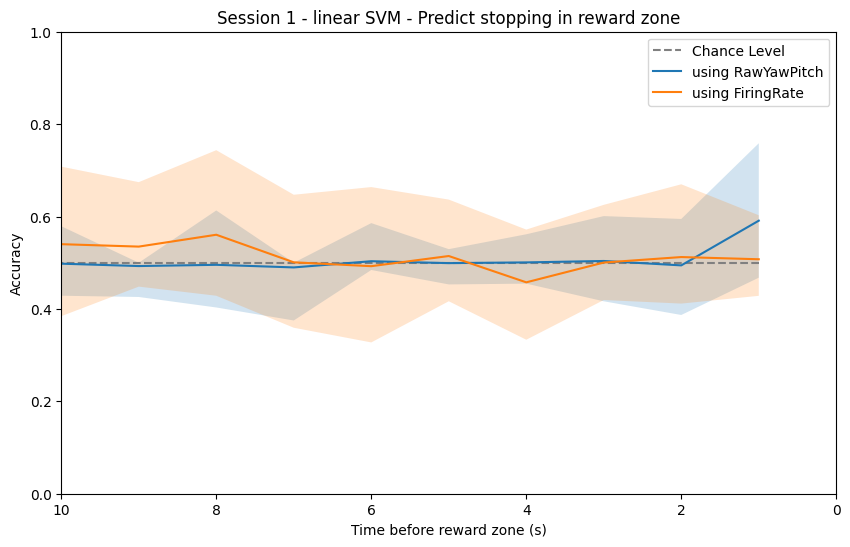

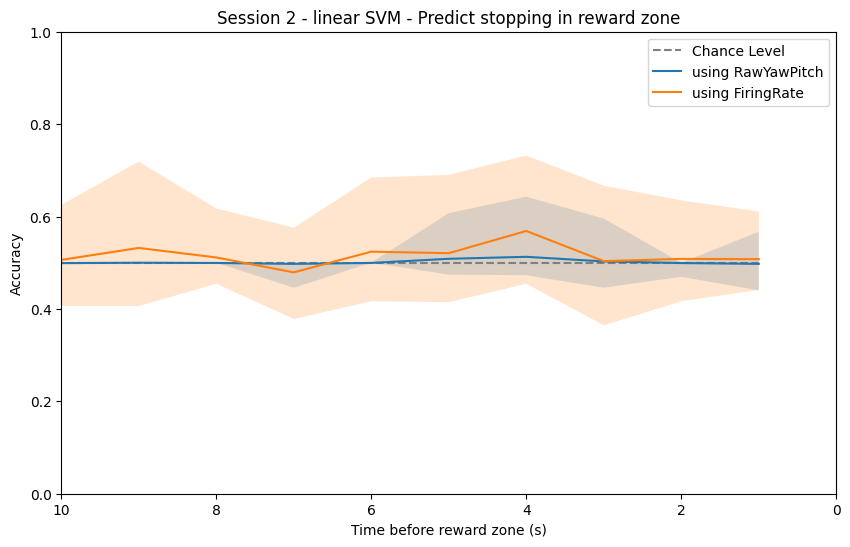

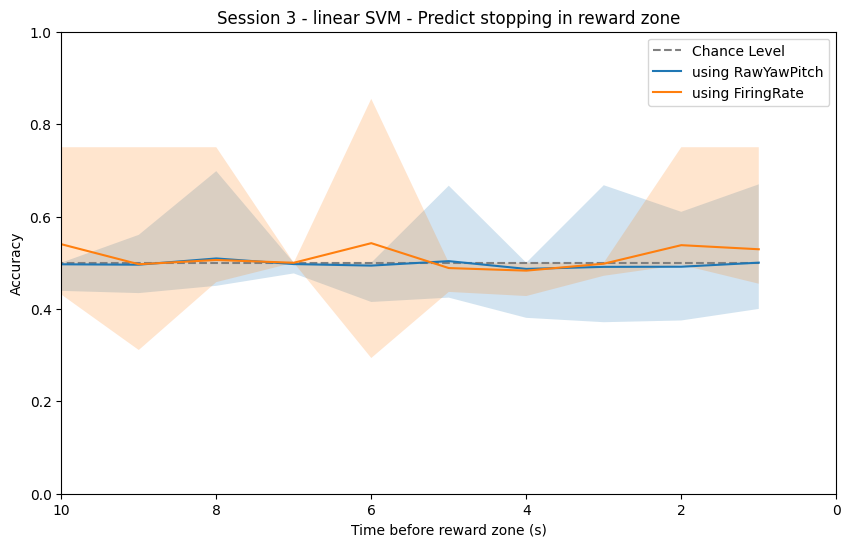

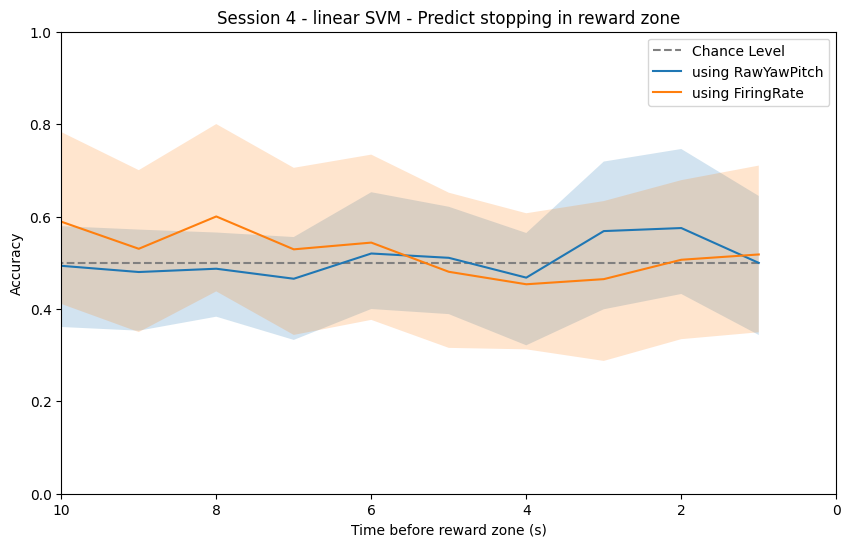

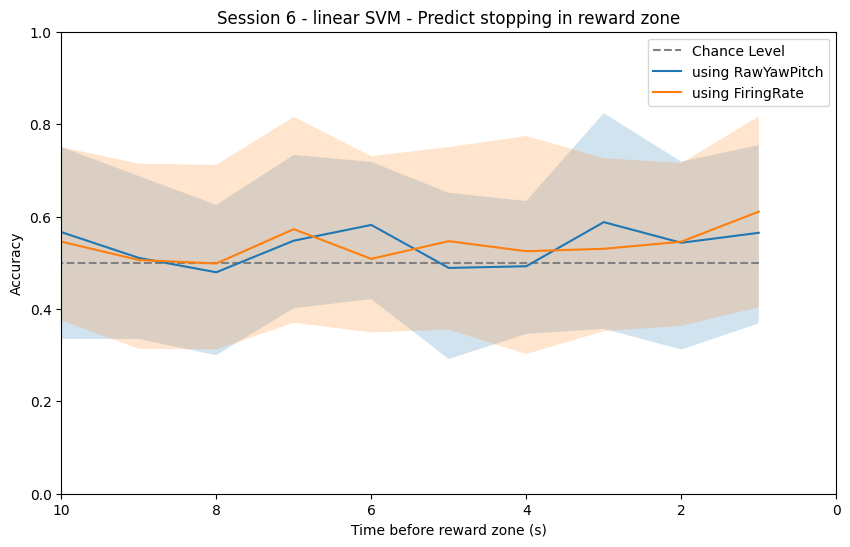

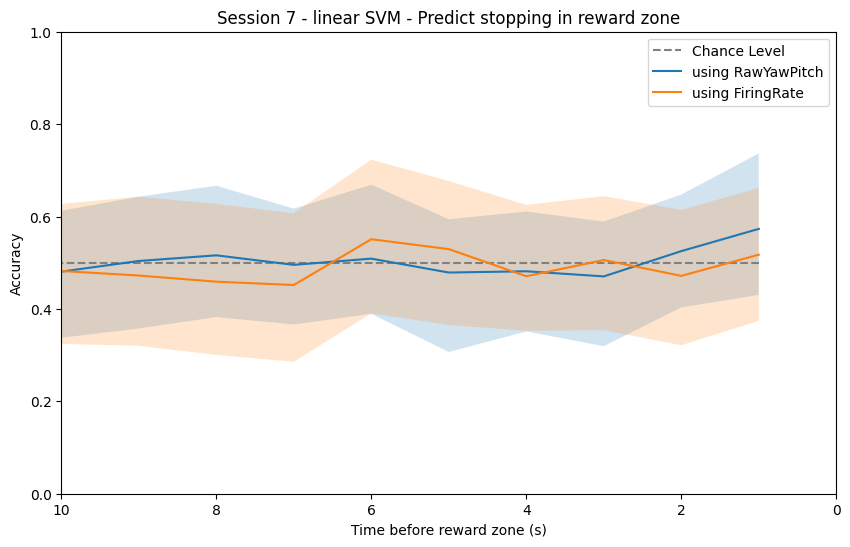

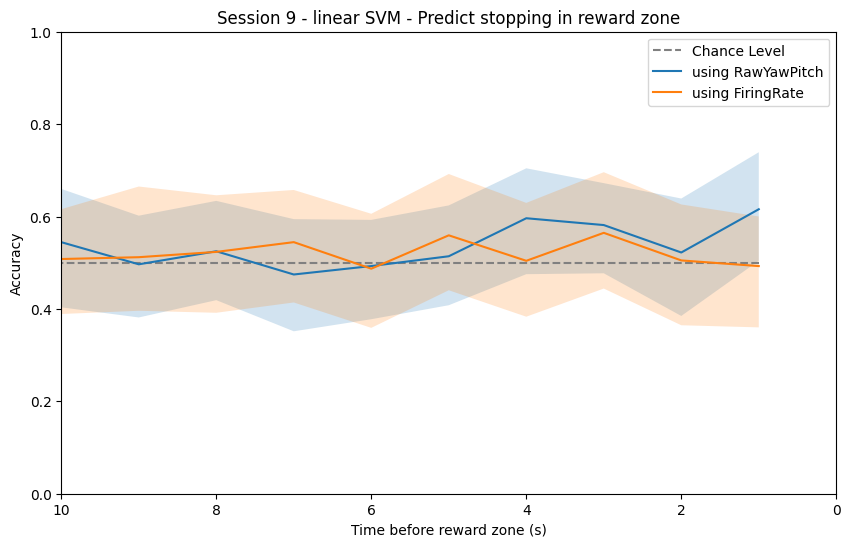

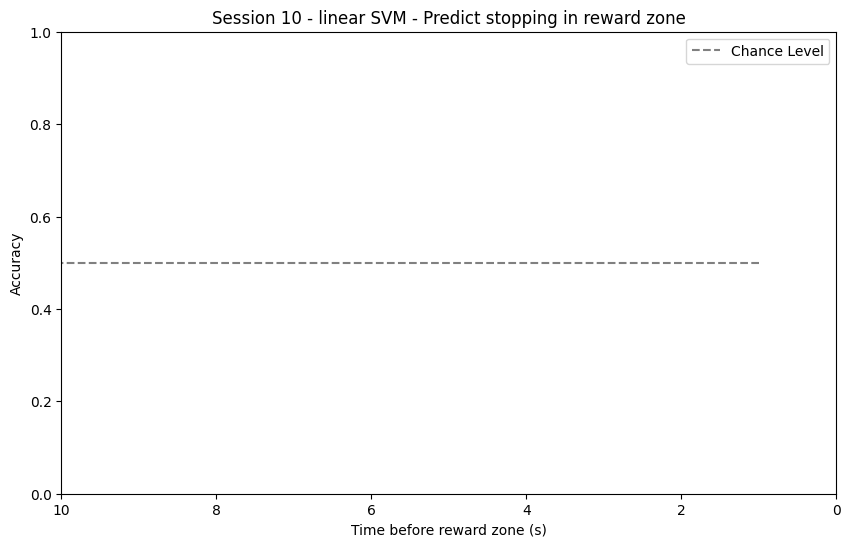

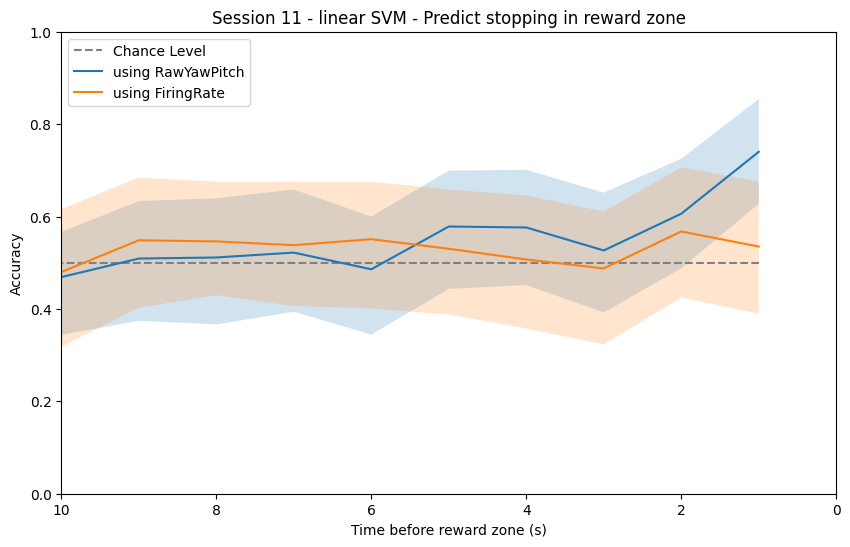

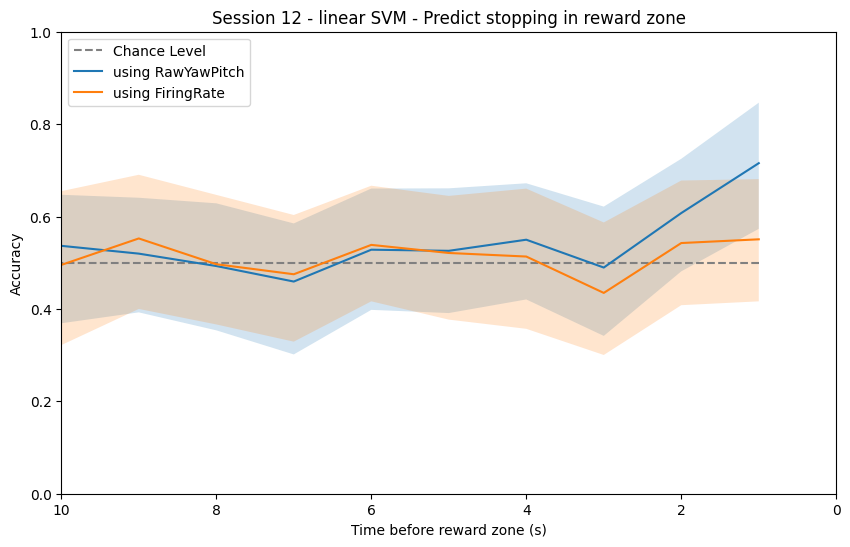

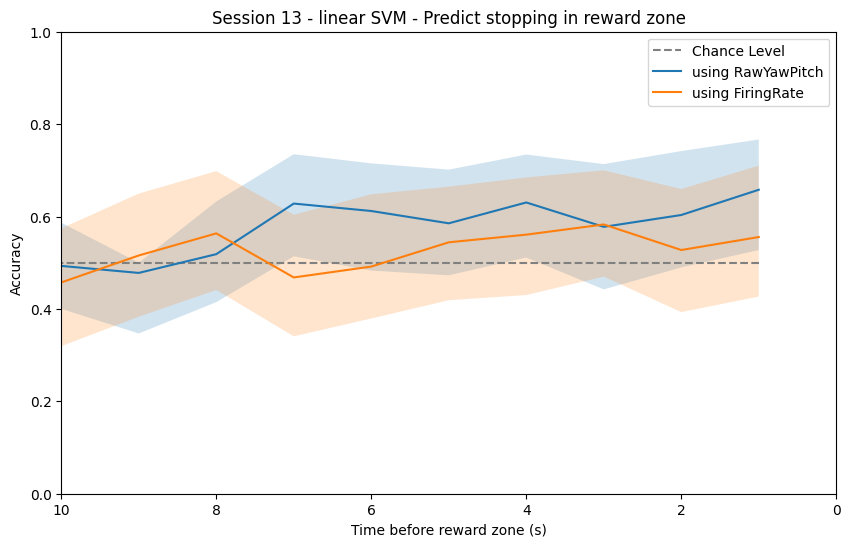

In [ ]:
kernel = 'linear'
for s_id in data.index.unique("session_id"):
    dat = data.xs(s_id, level="session_id")

    dat = dat[dat.kernel == kernel]
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Session {s_id} - {kernel} SVM - Predict stopping in reward zone")
    plt.hlines(0.5, 1, 10, colors='gray', linestyles='dashed', label='Chance Level')
    for name in dat.name.unique():
        datn = dat[dat.name == name]
        plt.plot(datn.t, datn.acc_mean, label="using "+name)
        # confidence interval shading
        # plt.fill_between(datn.t, datn.acc_ci_lower, datn.acc_ci_upper, alpha=0.2)
        # error bars
        plt.errorbar(datn.t, datn.acc_mean, yerr=datn.acc_ci_upper - datn.acc_mean, fmt='o', capsize=5)

    plt.legend()
    plt.title(f"Session {s_id} - {kernel} SVM - Predict stopping in reward zone")
    plt.xlabel("Time before reward zone (s)")
    plt.xlim(10, 0)
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.show()
